# Netflix Movies & TV Shows Analysis

## Mini Project - Exploratory Data Analysis (EDA)

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset. The analysis aims to understand Netflix's content library by exploring trends in content type, countries, release years, ratings, genres, and movie durations.

The project also focuses on generating meaningful business insights that can help Netflix understand audience preferences and support strategic decision-making.

## Import Required Libraries

The following Python libraries are used throughout this project for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import warnings
# warnings.filterwarnings("ignore")

## Load Dataset

The Netflix Movies and TV Shows dataset is loaded into a pandas DataFrame for analysis.

In [ ]:
df = pd.read_csv("NetFlix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


## Dataset Understanding

Before performing analysis, it is important to understand the structure of the dataset.

This section examines:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic statistical information

In [4]:
df.shape

(7787, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [7]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [9]:
df.duplicated().sum()

0

### Observations

- The dataset contains information about Netflix Movies and TV Shows.
- Both numerical and categorical columns are present.
- Several columns contain missing values, especially Director, Cast and Country.
- Duplicate records need to be checked before analysis.

# Data Cleaning

Data cleaning improves data quality by handling missing values, removing duplicates, and ensuring consistent formatting.

Cleaning is an essential step before performing analysis because inaccurate or incomplete data can produce misleading results.

In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [15]:
# Fill missing categorical values
df['director'] = df['director'].fillna("Unknown")

df['cast'] = df['cast'].fillna("Not Available")

df['country'] = df['country'].fillna("Unknown")

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format="%B %d, %Y",
    errors="coerce"
)

In [18]:


# Check remaining missing values
df['date_added'].isnull().sum()

10

In [19]:
df['date_added'].isna().sum()

10

### Observations

- Duplicate records were removed.
- Missing values in the Director, Cast, Country, and Rating columns were handled appropriately.
- The `date_added` column was converted to datetime format.
- Ten records had missing `date_added` values, which were converted to `NaT` and retained since they represent a very small portion of the dataset.
- The dataset is now clean and ready for exploratory data analysis.

# Task 3: Content Type Analysis

## Objective

Netflix offers two primary types of content: Movies and TV Shows.

The objective of this analysis is to determine the number of Movies and TV Shows available on the platform, calculate their percentage distribution, and visualize the results using different charts.

This analysis helps understand Netflix's content strategy and whether the platform focuses more on movies or television shows.

In [21]:
#Count Content Types
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [22]:
#Total Number of Movies
movies = (df['type'] == 'Movie').sum()
movies

5377

In [23]:
#Total Number of TV Shows
tv_shows = (df['type'] == 'TV Show').sum()
tv_shows

2410

In [30]:
#Percentage Distribution
content_percentage = df['type'].value_counts(normalize=True) * 100

content_percentage.round(2)

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64

### Understanding `normalize=True`

The `normalize=True` parameter in the `value_counts()` function returns the relative frequency (proportion) of each unique value instead of the actual count. Multiplying the result by 100 converts these proportions into percentages, making it easier to compare the distribution of different content types.

### Count Plot of Content Type

The count plot provides a comparison of the number of Movies and TV Shows available on Netflix.

C:\Users\Dilawar Singh\AppData\Local\Temp\ipykernel_2992\928439842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


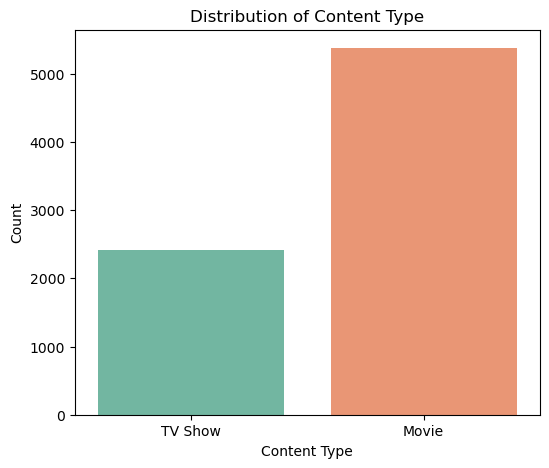

In [33]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='type',
    data=df,
    palette='Set2'
)

plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

### Percentage Distribution of Content Type

The pie chart represents the proportion of Movies and TV Shows available on Netflix.

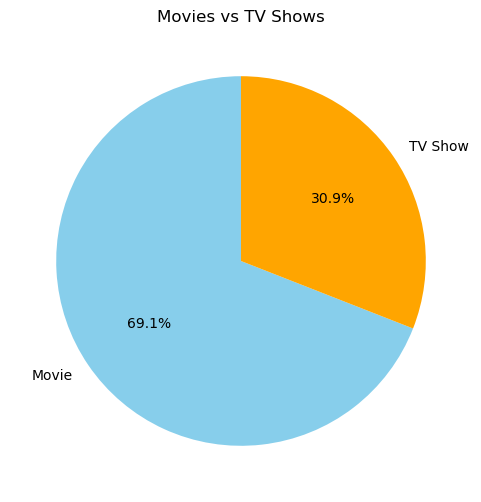

In [34]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','orange']
)

plt.ylabel("")
plt.title("Movies vs TV Shows")

plt.show()

## Observations

- Netflix contains both Movies and TV Shows in its content library.
- Movies significantly outnumber TV Shows.
- More than two-thirds of the available content consists of Movies.
- TV Shows represent a smaller but important portion of the platform.
- The visualizations clearly indicate Netflix's stronger focus on movie content.

## Business Interpretation

The analysis indicates that Netflix has invested more heavily in Movies than TV Shows. This suggests that movies remain the platform's primary content offering due to their broad audience appeal and lower production commitment compared to multi-season television series.

However, TV Shows continue to play an important role in attracting long-term subscribers through episodic content and binge-watching experiences.

# Task 4: Country Analysis

## Objective

Netflix content is produced across many countries worldwide. This analysis identifies the countries that contribute the most titles to Netflix's library.

Understanding the geographical distribution of content helps reveal Netflix's strongest production markets and regions where content investment is concentrated.

In [35]:
#Split Multiple Countries
country_df = df.copy()

country_df['country'] = country_df['country'].str.split(',')

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip()

In [36]:
top_countries = country_df['country'].value_counts().head(10)

top_countries

country
United States     3297
India              990
United Kingdom     723
Unknown            507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64

In [42]:
# excluding unknown cuntries
top_countries = (
    country_df[country_df['country'] != 'Unknown']['country']
    .value_counts()
    .head(10)
)
top_countries

country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

### Top 10 Content-Producing Countries

The following bar chart shows the countries with the highest number of Movies and TV Shows available on Netflix.

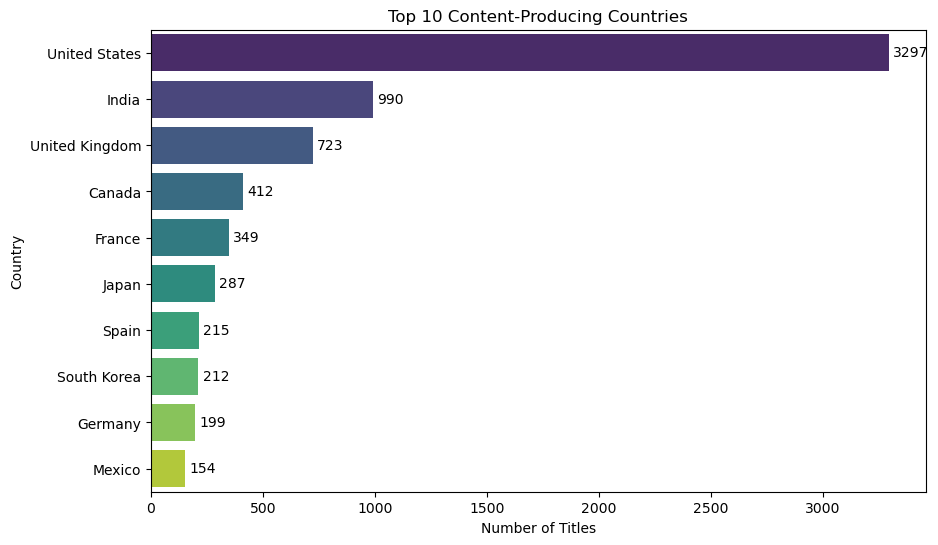

In [46]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='viridis',
    legend=False
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [47]:
#Percentage Contribution
country_percentage = (
    top_countries / top_countries.sum()
) * 100

country_percentage.round(2)

country
United States     48.22
India             14.48
United Kingdom    10.57
Canada             6.03
France             5.10
Japan              4.20
Spain              3.14
South Korea        3.10
Germany            2.91
Mexico             2.25
Name: count, dtype: float64

## Observations

- The United States is the largest content-producing country on Netflix, with **3,297** titles.
- India ranks second with **990** titles, indicating its significant contribution to Netflix's content library.
- The United Kingdom, Canada, France, Japan, Spain, South Korea, and Germany are also among the top content-producing countries.
- The presence of **507 'Unknown'** entries indicates that country information is missing for some titles.
- The distribution shows that Netflix's content production is concentrated in a few major countries.

## Business Interpretation

The analysis reveals that Netflix's content catalog is dominated by productions from the United States and India. This reflects Netflix's strong presence in these markets and their large entertainment industries. Increasing investments in underrepresented regions could diversify the content library, attract new audiences, and strengthen Netflix's global reach.

# Task 5: Yearly Trend Analysis

## Objective

The release year of a title helps identify how Netflix's content library has evolved over time.

This analysis examines the number of Movies and TV Shows released each year to determine whether content production has increased, decreased, or remained stable over the years.

In [48]:
#Count Titles by Release Year
yearly_content = df['release_year'].value_counts().sort_index()

yearly_content.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    3
Name: count, dtype: int64

### Year-wise Content Distribution

The following visualizations show how the number of Movies and TV Shows released has changed over time. The line chart highlights the overall trend, while the bar chart provides the exact distribution across release years.

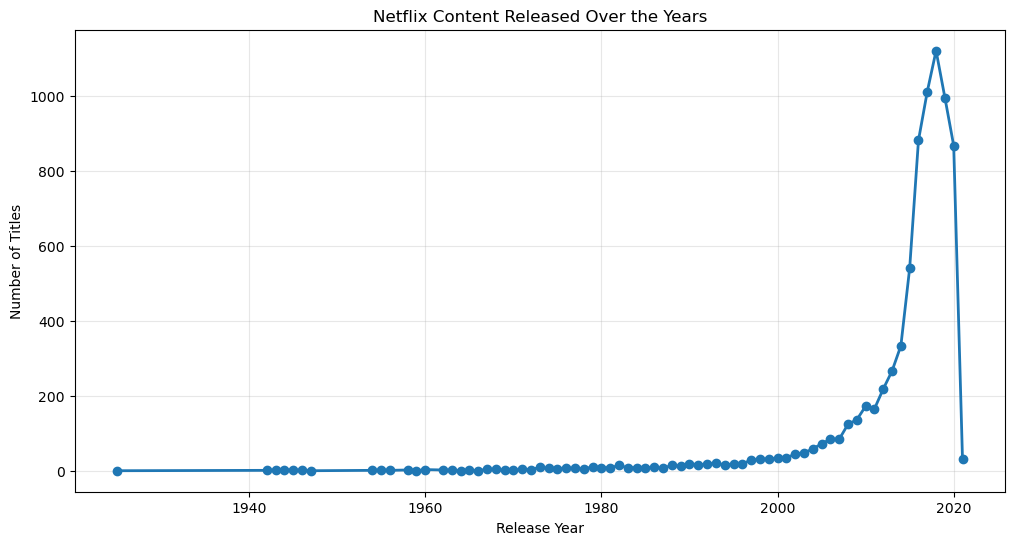

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o',
    linewidth=2
)

plt.title("Netflix Content Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.show()

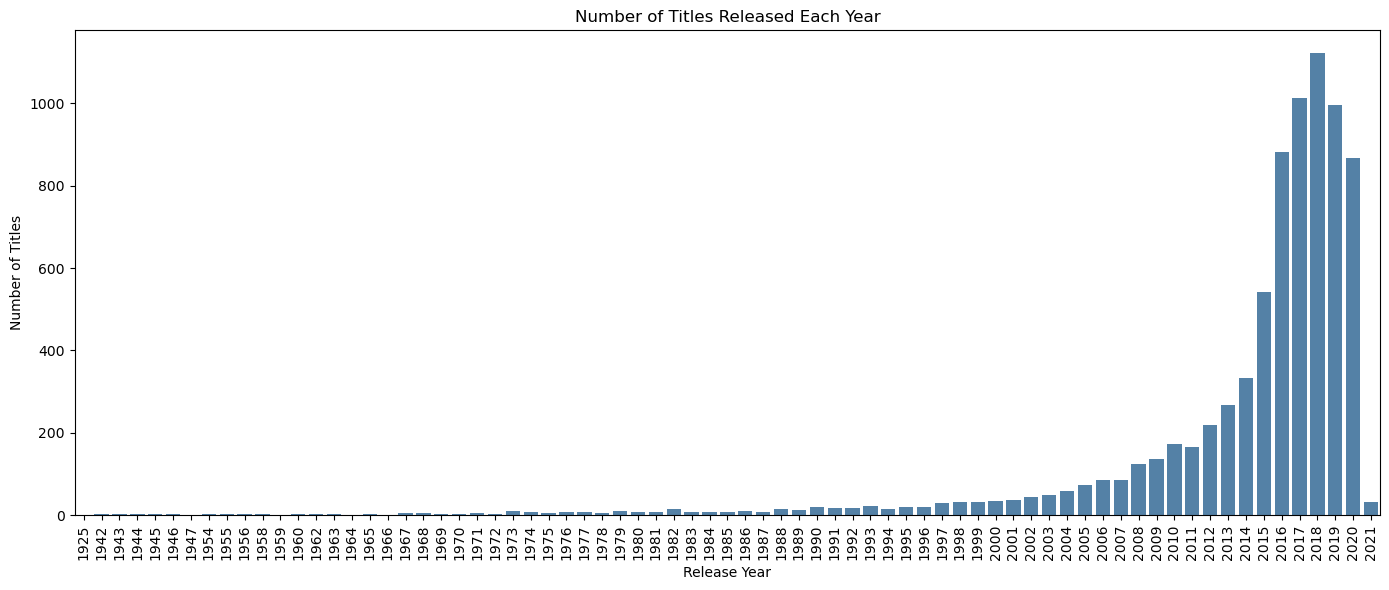

In [50]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=yearly_content.index,
    y=yearly_content.values,
    color='steelblue'
)

plt.title("Number of Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

## Observations

- Netflix's content releases remained relatively low from 1925 to the early 2000s.
- A steady increase in the number of titles can be observed after 2005.
- The most significant growth occurred between 2015 and 2019, indicating a rapid expansion of Netflix's content library.
- The highest number of titles was released around 2019, making it the peak year in the dataset.
- A sharp decline is visible after 2020; however, this is likely due to incomplete data for the latest year rather than a reduction in content production.

# Task 6: Rating Analysis

## Objective

Netflix classifies its content using maturity ratings to help viewers identify age-appropriate titles. This analysis explores the distribution of these ratings to determine which audience groups Netflix primarily serves.

The analysis identifies the most common ratings and visualizes their distribution.

In [51]:
# Count Ratings
rating_count = df['rating'].value_counts()

rating_count

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [52]:
print("Most Common Rating :", df['rating'].mode()[0])

Most Common Rating : TV-MA


### Distribution of Content Ratings

The following visualization illustrates the frequency of different maturity ratings assigned to Netflix Movies and TV Shows. This helps identify the primary audience targeted by the platform.

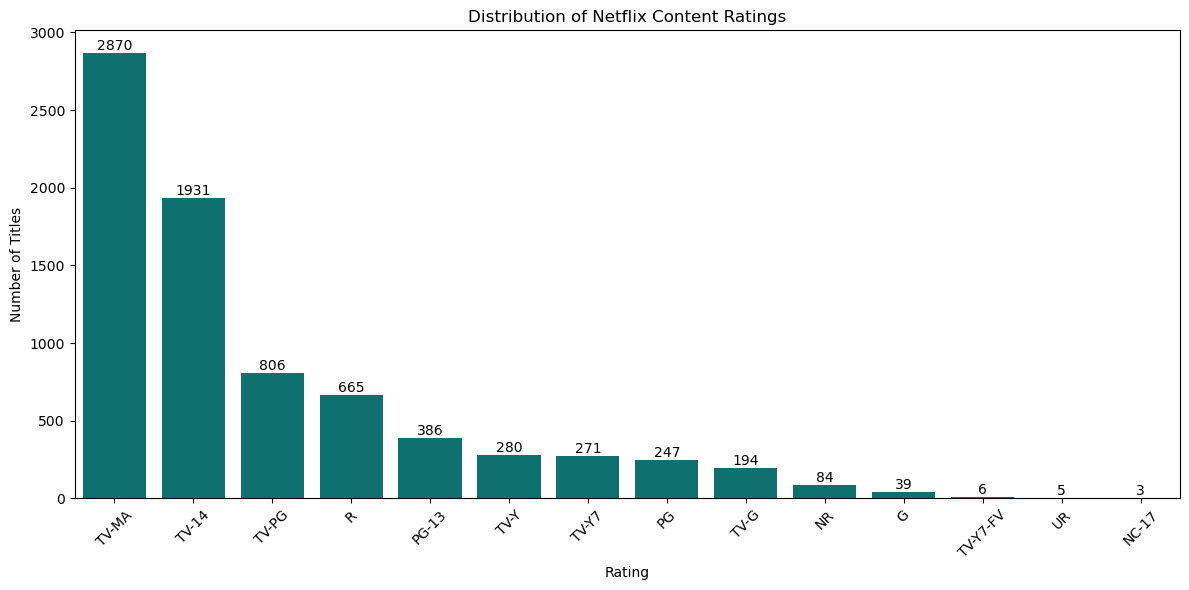

In [55]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='rating',
    data=df,
    order=df['rating'].value_counts().index,
    color='teal'
)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [54]:
# Percenatge distribution
rating_percentage = (
    df['rating'].value_counts(normalize=True) * 100
).round(2)

rating_percentage

rating
TV-MA       36.86
TV-14       24.80
TV-PG       10.35
R            8.54
PG-13        4.96
TV-Y         3.60
TV-Y7        3.48
PG           3.17
TV-G         2.49
NR           1.08
G            0.50
TV-Y7-FV     0.08
UR           0.06
NC-17        0.04
Name: proportion, dtype: float64

## Observations

- **TV-MA** is the most common content rating on Netflix, with **2,870** titles.
- **TV-14** is the second most common rating, containing **1,931** titles.
- Ratings such as **TV-PG**, **R**, and **PG-13** also represent a significant portion of the content library.
- Very few titles are rated **NC-17**, **UR**, and **TV-Y7-FV**, indicating that highly restricted or uncommon ratings are rare.
- Overall, Netflix's content catalog is primarily targeted toward teenagers and mature audiences.

## Business Interpretation

The rating distribution shows that Netflix primarily focuses on producing content for mature viewers and teenagers, as reflected by the dominance of TV-MA and TV-14 ratings. While family-friendly content is available, it represents a smaller share of the platform's catalog. This strategy aligns with the viewing preferences of Netflix's largest subscriber base and supports a diverse range of entertainment options.

# Task 7: Genre Analysis

## Objective

Genres help categorize Netflix content based on themes and storytelling styles. This analysis identifies the most common genres available on the platform and highlights the categories that dominate Netflix's content library.

Understanding genre distribution helps Netflix recognize audience preferences and make informed content investment decisions.

In [56]:
genre_df = df.copy()

genre_df['genres'] = genre_df['genres'].str.split(',')

genre_df = genre_df.explode('genres')

genre_df['genres'] = genre_df['genres'].str.strip()

In [57]:
top_genres = genre_df['genres'].value_counts().head(10)

top_genres

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

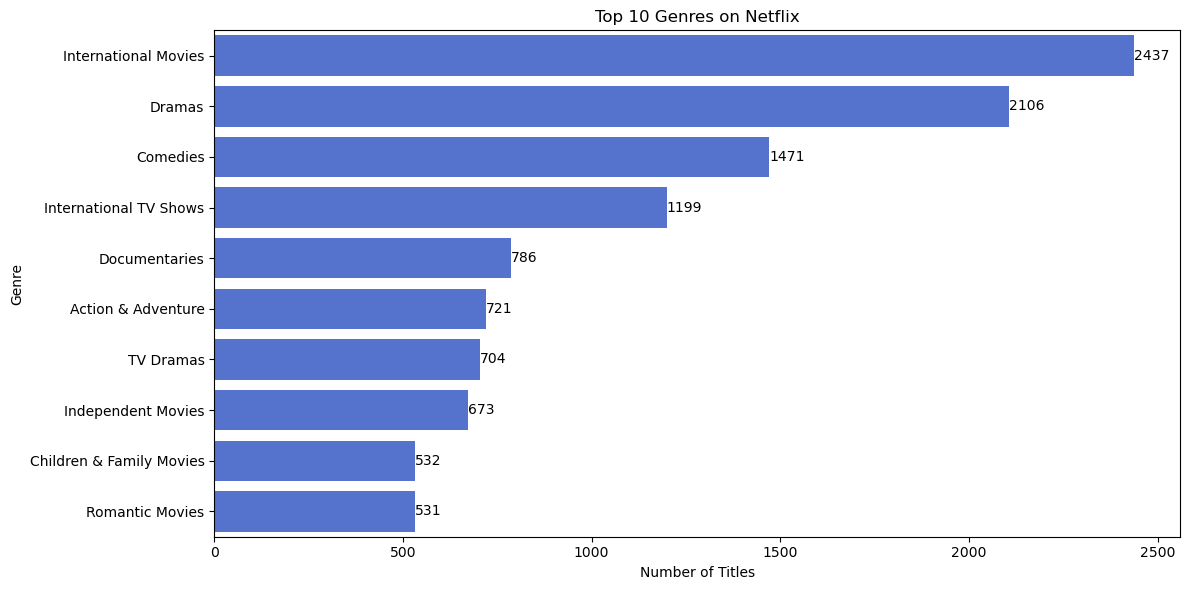

In [58]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    color='royalblue'
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [59]:
genre_percentage = (
    top_genres / top_genres.sum() * 100
).round(2)

genre_percentage

genres
International Movies        21.84
Dramas                      18.87
Comedies                    13.18
International TV Shows      10.74
Documentaries                7.04
Action & Adventure           6.46
TV Dramas                    6.31
Independent Movies           6.03
Children & Family Movies     4.77
Romantic Movies              4.76
Name: count, dtype: float64

## Observations

- **International Movies** is the most common genre on Netflix, with **2,437** titles.
- **Dramas** rank second with **2,106** titles, followed by **Comedies** with **1,471** titles.
- **International TV Shows** also contribute significantly, with **1,199** titles.
- Documentary, Action & Adventure, TV Dramas, and Independent Movies have a strong presence, indicating a diverse content library.
- Family-oriented genres such as **Children & Family Movies** and **Romantic Movies** appear in the top ten but contribute fewer titles than international and drama-based content.

## Business Interpretation

The analysis indicates that Netflix places a strong emphasis on international and drama-based content, reflecting its strategy of serving a global audience with diverse storytelling. The popularity of genres such as Comedies, Documentaries, and Action & Adventure demonstrates the platform's effort to cater to varied viewer preferences while maintaining a balanced content portfolio.

# Task 8: Duration Analysis

## Objective

Movie duration is an important characteristic that influences viewer preferences and content planning. This analysis focuses on movie durations to determine the average runtime, identify the longest and shortest movies, and examine how movie durations are distributed across the Netflix library.

In [60]:
movies_df = df[df['type'] == 'Movie'].copy()

movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2019-02-25,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",2021-01-01,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...


In [62]:
df['duration'].dtype

dtype('int64')

In [64]:
movies_df['duration'].head(10)

1     143
2     124
3      90
5      90
6      94
7     112
8     129
9      85
11    108
12     60
Name: duration, dtype: int64

In [63]:
movies_df['duration'].isna().sum()

0

In [67]:
average_duration = movies_df['duration'].mean()

print(f"Average Movie Duration: {average_duration:.2f} minutes")

Average Movie Duration: 99.31 minutes


In [68]:
longest_movie = movies_df.loc[
    movies_df['duration'].idxmax(),
    ['title', 'duration']
]

longest_movie

title       Black Mirror: Bandersnatch
duration                           312
Name: 7741, dtype: object

In [69]:
shortest_movie = movies_df.loc[
    movies_df['duration'].idxmin(),
    ['title', 'duration']
]

shortest_movie

title       Silent
duration         3
Name: 5119, dtype: object

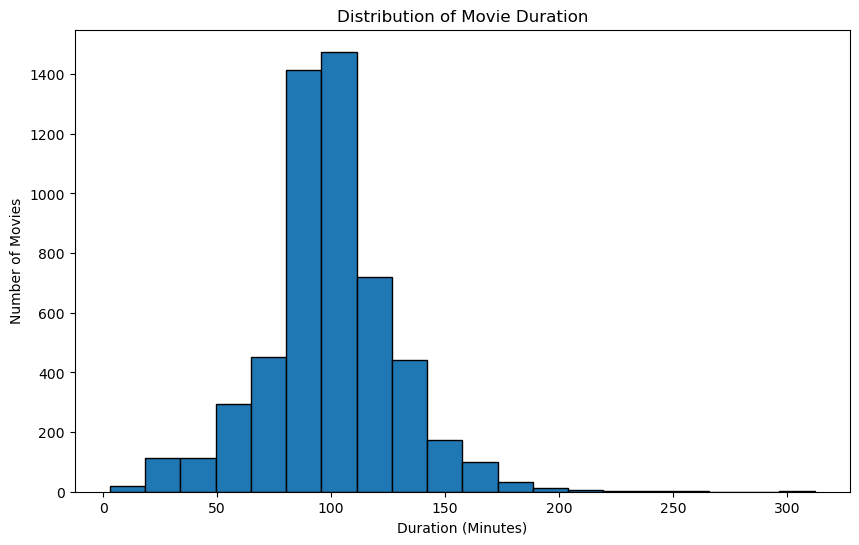

In [70]:
plt.figure(figsize=(10,6))

plt.hist(
    movies_df['duration'],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

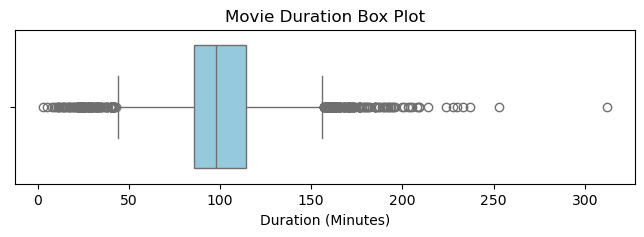

In [73]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=movies_df['duration'],
    color='skyblue'
)

plt.title("Movie Duration Box Plot")
plt.xlabel("Duration (Minutes)")

plt.show()

## Observations

- The average movie duration on Netflix is **99.31 minutes**, indicating that most movies are approximately one and a half hours long.
- **Black Mirror: Bandersnatch** is the longest movie in the dataset with a duration of **312 minutes**.
- **Silent** is the shortest movie with a duration of **3 minutes**.
- The histogram shows that the majority of movies have durations between **80 and 120 minutes**, forming a roughly bell-shaped distribution.
- The box plot reveals the presence of several outliers, representing exceptionally short and exceptionally long movies.

## Business Interpretation

The analysis suggests that Netflix primarily offers movies with standard feature-length durations, which align with typical audience viewing preferences. Extremely short and exceptionally long movies are relatively rare and cater to niche audiences. Understanding duration trends helps Netflix optimize its content strategy by balancing viewer engagement with content diversity.

# Task 9: Outlier Analysis

## Objective

Outliers are data points that differ significantly from the majority of observations. Identifying outliers helps detect unusual movie durations that may influence statistical analysis.

In this section, movie duration outliers are identified using both the Interquartile Range (IQR) method and the Z-score method, and the results are compared.

In [74]:
# Calculate Quartiles
Q1 = movies_df['duration'].quantile(0.25)
Q3 = movies_df['duration'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

Q1 : 86.0
Q3 : 114.0
IQR : 28.0


In [75]:
# Calculate Bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Lower Bound : 44.0
Upper Bound : 156.0


In [76]:
# Find Outliers
iqr_outliers = movies_df[
    (movies_df['duration'] < lower_bound) |
    (movies_df['duration'] > upper_bound)
]

print("Number of Outliers (IQR):", len(iqr_outliers))

Number of Outliers (IQR): 337


In [77]:
# view outliers
iqr_outliers[['title', 'duration']].head(10)

,title,duration
13,3 Idiots,164
21,Bobby,168
29,Bogda,161
32,BoJack Horseman Christmas Special: Sabrina's C...,26
145,Buddy Thunderstruck: The Maybe Pile,14
176,Bye Bye London,177
197,Calico Critters: A Town of Dreams,11
198,Calico Critters: Everyone's Big Dream Flying i...,11
199,Calico Critters: The Treasure of Calico Village,22
229,Canvas,9


In [78]:
# Z-Score Method

In [79]:
from scipy.stats import zscore

In [80]:
movies_df['z_score'] = zscore(movies_df['duration'])

In [81]:
z_outliers = movies_df[
    movies_df['z_score'].abs() > 3
]

print("Number of Outliers (Z-score):", len(z_outliers))

Number of Outliers (Z-score): 45


In [82]:
z_outliers[['title', 'duration', 'z_score']].head(10)

,title,duration,z_score
197,Calico Critters: A Town of Dreams,11,-3.095460
198,Calico Critters: Everyone's Big Dream Flying i...,11,-3.095460
229,Canvas,9,-3.165566
560,Cops and Robbers,8,-3.200619
563,Cosmos Laundromat: First Cycle,12,-3.060407
843,Dil Chahta Hai,185,3.003763
883,Doctor Zhivago,200,3.529558
1082,Elephants Dream 4 Hour,196,3.389346
1286,Fifty Year Old Teenager,204,3.669770
2068,Hum Aapke Hain Koun,193,3.284187


In [83]:
# compare results
print("IQR Outliers :", len(iqr_outliers))
print("Z-score Outliers :", len(z_outliers))

IQR Outliers : 337
Z-score Outliers : 45


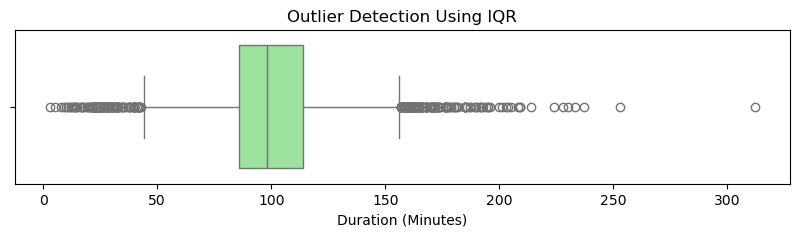

In [84]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=movies_df['duration'],
    color='lightgreen'
)

plt.title("Outlier Detection Using IQR")
plt.xlabel("Duration (Minutes)")

plt.show()

### Detecting Outliers

Two statistical methods are used to identify unusual movie durations:

- **Interquartile Range (IQR):** Detects values lying beyond 1.5 times the interquartile range.
- **Z-score:** Identifies observations that are more than three standard deviations away from the mean.

Comparing both methods provides a better understanding of extreme values in the dataset.

## Observations

- The first quartile (Q1) of movie duration is **86 minutes**, while the third quartile (Q3) is **114 minutes**.
- The Interquartile Range (IQR) is **28 minutes**, resulting in a lower bound of **44 minutes** and an upper bound of **156 minutes**.
- Using the IQR method, **337 movies** were identified as outliers because their durations fall outside the calculated range.
- The Z-score method identified **45 outliers**, representing movies with durations more than three standard deviations away from the mean.
- The IQR method detected considerably more outliers than the Z-score method, making it more sensitive to moderately unusual movie durations.

## Comparison of Outlier Detection Methods

| Method | Number of Outliers |
|---------|-------------------:|
| IQR Method | 337 |
| Z-Score Method | 45 |

The IQR method identified a larger number of outliers because it is based on the spread of the middle 50% of the data and is less influenced by extreme values. In contrast, the Z-score method relies on the mean and standard deviation, making it more suitable for identifying only the most extreme observations.

## Business Interpretation

The presence of unusually short and unusually long movies indicates that Netflix offers content for a wide variety of audiences and viewing preferences. While most movies follow the standard feature-length duration, outliers such as very short films and extended productions contribute to the diversity of the platform's catalog. Identifying these outliers helps analysts understand the overall distribution of movie durations and supports better statistical analysis.

# Task 10: Feature Engineering

## Objective

Feature engineering is the process of creating new variables from existing data to improve analysis and extract additional insights.

In this section, three new features are created:

- **Release Decade** – Groups titles according to the decade in which they were released.
- **Content Age** – Calculates how old each title is based on its release year.
- **Duration Category** – Classifies movies as Short, Medium, or Long based on their duration.

In [85]:
df['release_decade'] = (df['release_year'] // 10) * 10

df[['release_year', 'release_decade']].head()

,release_year,release_decade
0,2020,2020
1,2008,2000
2,2016,2010
3,2016,2010
4,2017,2010


In [86]:
decade_count = df['release_decade'].value_counts().sort_index()

decade_count

release_decade
1920       1
1940      14
1950      11
1960      25
1970      67
1980     106
1990     225
2000     728
2010    5711
2020     899
Name: count, dtype: int64

### Feature Engineering Analysis

The newly created features provide additional insights into Netflix's content library. Release decade highlights long-term production trends, content age indicates how recent the catalog is, and duration category classifies movies into meaningful groups for easier comparison.

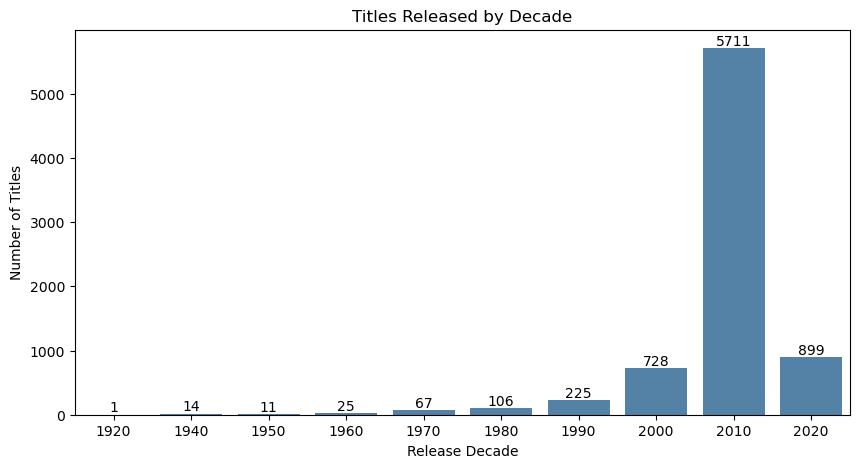

In [94]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x='release_decade',
    data=df,
    color='steelblue'
)

ax.bar_label(ax.containers[0])

plt.title("Titles Released by Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")

plt.show()

In [95]:
#Content Age
current_year = 2021

df['content_age'] = current_year - df['release_year']

df[['release_year', 'content_age']].head()

,release_year,content_age
0,2020,1
1,2008,13
2,2016,5
3,2016,5
4,2017,4


In [96]:
df['content_age'].describe()

count    7787.000000
mean        7.067420
std         8.757395
min         0.000000
25%         3.000000
50%         4.000000
75%         8.000000
max        96.000000
Name: content_age, dtype: float64

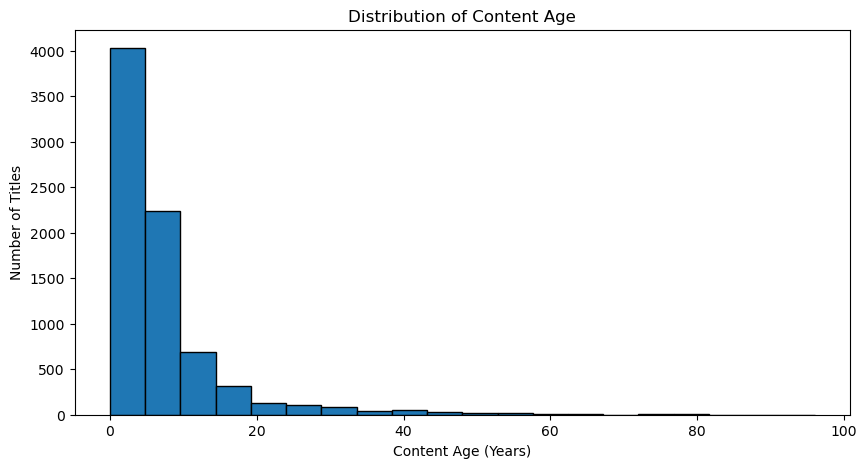

In [97]:
plt.figure(figsize=(10,5))

plt.hist(
    df['content_age'],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Content Age")
plt.xlabel("Content Age (Years)")
plt.ylabel("Number of Titles")

plt.show()

In [98]:
# Duration Category
movies_df['duration_category'] = pd.cut(
    movies_df['duration'],
    bins=[0, 60, 120, float('inf')],
    labels=['Short', 'Medium', 'Long']
)

movies_df[['duration', 'duration_category']].head()

,duration,duration_category
1,143,Long
2,124,Long
3,90,Medium
5,90,Medium
6,94,Medium


In [99]:
duration_category_count = movies_df['duration_category'].value_counts()

duration_category_count

duration_category
Medium    3920
Long      1011
Short      446
Name: count, dtype: int64

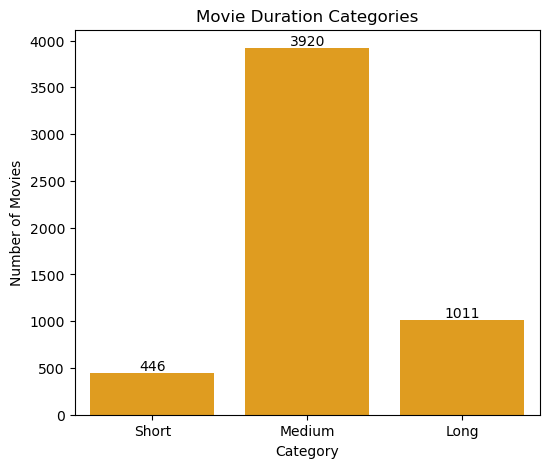

In [100]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='duration_category',
    data=movies_df,
    order=['Short', 'Medium', 'Long'],
    color='orange'
)

ax.bar_label(ax.containers[0])

plt.title("Movie Duration Categories")
plt.xlabel("Category")
plt.ylabel("Number of Movies")

plt.show()

## Observations

### Release Decade

- The **2010s** dominate Netflix's content library with **5,711 titles**, making it the most productive decade.
- The **2020s** contain **899 titles**; however, this decade is only partially represented in the dataset.
- Content released before the 1980s represents only a very small portion of the Netflix catalog.
- The number of titles has increased significantly from the **2000s onwards**, reflecting Netflix's rapid expansion during the last two decades.

### Content Age

- The average content age is **7.07 years**, indicating that most titles on Netflix are relatively recent.
- Half of the titles are **4 years old or newer**, showing Netflix's focus on recent releases.
- The oldest title in the dataset is **96 years old**, demonstrating that Netflix also preserves classic content.
- The histogram shows that the majority of titles were released within the last **10 years**.

### Duration Category

- **Medium-length movies (60–120 minutes)** are the most common category, with **3,920** titles.
- **Long movies (>120 minutes)** account for **1,011** titles.
- **Short movies (<60 minutes)** are the least common, with **446** titles.
- The distribution indicates that Netflix primarily offers standard feature-length movies.

## Business Interpretation

The feature engineering analysis reveals that Netflix primarily focuses on recently released, feature-length content. The dominance of titles from the 2010s and the relatively low average content age suggest continuous investment in fresh content. Additionally, the prevalence of medium-duration movies aligns with typical audience viewing preferences, while shorter and longer productions cater to specific viewer interests.

# Task 11: Multivariate Analysis

## Objective

Multivariate analysis examines the relationship between two or more variables simultaneously. This helps identify patterns and interactions that cannot be observed through univariate analysis alone.

The following relationships are analyzed:

- Country vs Content Type
- Release Decade vs Content Type
- Rating vs Content Type

The analysis uses Crosstab, GroupBy, and Heatmaps to visualize these relationships.

In [101]:
country_type = pd.crosstab(
    df['country'],
    df['type']
)

country_type.head()

type,Movie,TV Show
country,,
Argentina,34,16
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0


In [102]:
top10_country_type = country_type.sort_values(
    by='Movie',
    ascending=False
).head(10)

top10_country_type

type,Movie,TV Show
country,,
United States,1850,705
India,852,71
Unknown,230,277
United Kingdom,193,204
Canada,118,59
Spain,89,45
Egypt,89,12
Turkey,73,27
Philippines,70,1


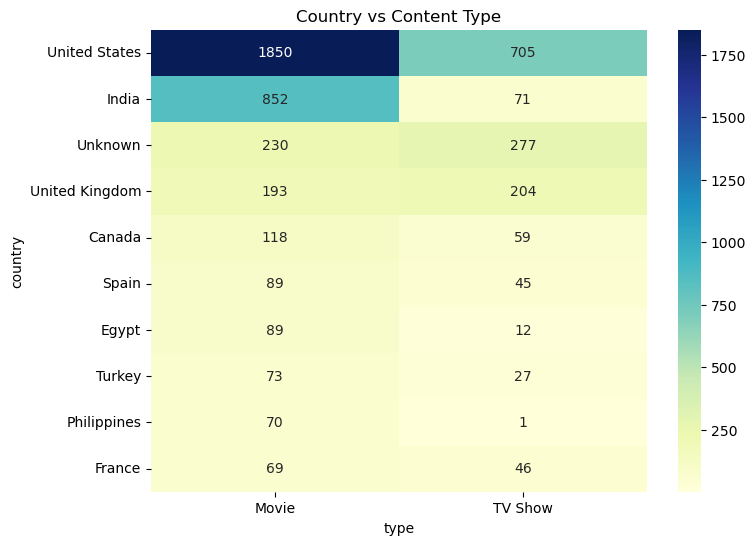

In [103]:
plt.figure(figsize=(8,6))

sns.heatmap(
    top10_country_type,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Country vs Content Type")

plt.show()

In [104]:
# Release Decade vs Content Type
decade_type = pd.crosstab(
    df['release_decade'],
    df['type']
)

decade_type

type,Movie,TV Show
release_decade,,
1920,0,1
1940,13,1
1950,11,0
1960,22,3
1970,63,4
1980,99,7
1990,194,31
2000,601,127
2010,3951,1760


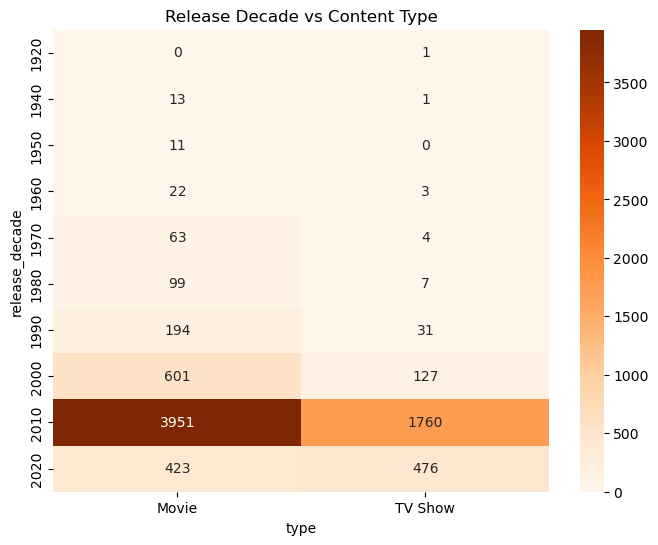

In [105]:
plt.figure(figsize=(8,6))

sns.heatmap(
    decade_type,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Release Decade vs Content Type")

plt.show()

In [106]:
# Rating vs Content Type
rating_type = pd.crosstab(
    df['rating'],
    df['type']
)

rating_type


type,Movie,TV Show
rating,,
G,39,0
NC-17,3,0
NR,79,5
PG,247,0
PG-13,386,0
R,663,2
TV-14,1272,659
TV-G,111,83
TV-MA,1850,1020


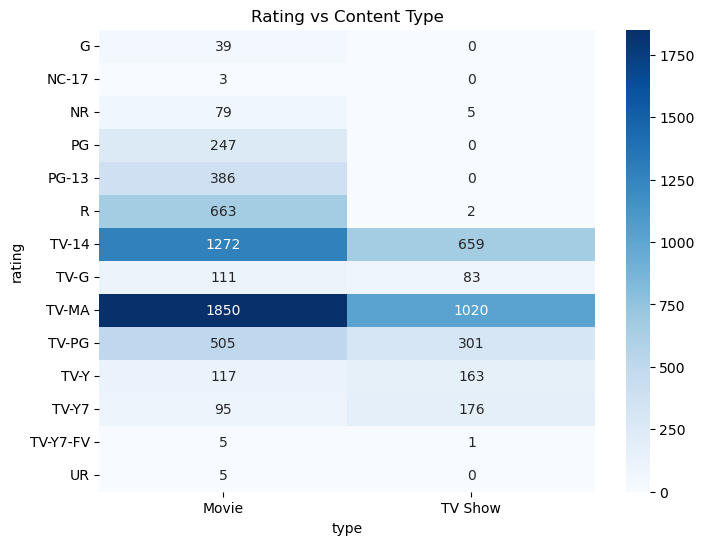

In [107]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rating_type,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Rating vs Content Type")

plt.show()

In [108]:
# GroupBy Analysis
# Average Movie Duration by Release Decade
average_duration = movies_df.groupby(
    (movies_df['release_year'] // 10) * 10
)['duration'].mean()

average_duration

release_year
1940     51.384615
1950    107.090909
1960    142.363636
1970    119.111111
1980    116.434343
1990    113.917526
2000    112.637271
2010     96.762086
2020     89.522459
Name: duration, dtype: float64

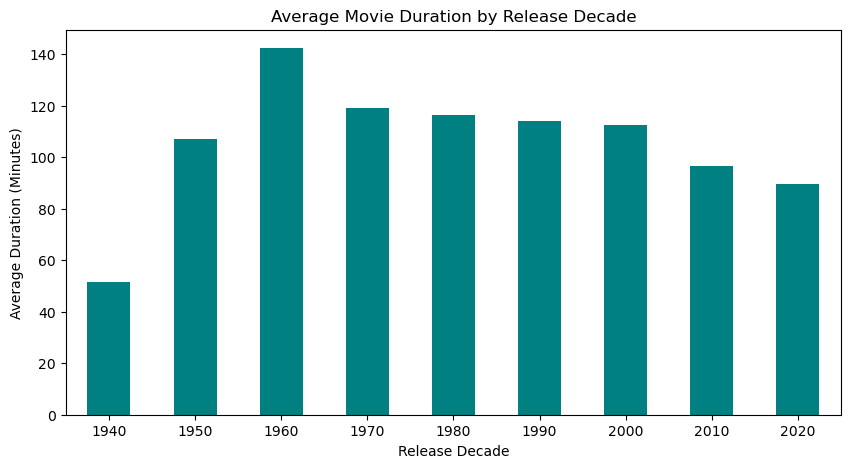

In [109]:
plt.figure(figsize=(10,5))

ax = average_duration.plot(
    kind='bar',
    color='teal'
)

plt.title("Average Movie Duration by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Average Duration (Minutes)")

plt.xticks(rotation=0)

plt.show()

## Observations

### Country vs Content Type

- The **United States** has the highest number of both Movies (**1,850**) and TV Shows (**705**), making it Netflix's largest content producer.
- **India** contributes primarily Movies (**852**) with relatively fewer TV Shows (**71**), indicating a strong focus on film production.
- The **United Kingdom** has a more balanced contribution of Movies (**193**) and TV Shows (**204**).
- Countries such as **Canada**, **Spain**, **France**, and **Turkey** contribute moderate amounts of both content types.
- The presence of **Unknown** entries suggests that country information is unavailable for some titles.

### Release Decade vs Content Type

- The **2010s** experienced the highest content production, with **3,951 Movies** and **1,760 TV Shows**.
- Content production increased dramatically from the **2000s onwards**, reflecting Netflix's rapid global expansion.
- Earlier decades contain significantly fewer titles.
- Movies consistently outnumber TV Shows across almost all decades.
- The **2020s** show fewer titles because the dataset contains only partial data for that decade.

### Rating vs Content Type

- **TV-MA** is the most common rating for both Movies and TV Shows.
- **TV-14** is the second most common rating across both content types.
- Ratings such as **PG**, **PG-13**, and **R** are primarily associated with Movies.
- Ratings like **TV-Y** and **TV-Y7** are more common among TV Shows, reflecting children's programming.
- Overall, Netflix's catalog is largely targeted toward mature audiences.

### Average Movie Duration by Release Decade

- Movies released during the **1960s** have the highest average duration.
- From the **1970s onward**, average movie duration gradually decreases.
- Movies released in the **2010s and 2020s** have comparatively shorter average durations.
- The decreasing trend suggests a shift toward more concise content that aligns with modern viewing habits.

## Business Interpretation

The multivariate analysis reveals that Netflix's content strategy is driven primarily by large production markets such as the United States and India. Most of the platform's content was released during the 2010s, reflecting Netflix's period of rapid growth and investment in original programming.

The dominance of TV-MA and TV-14 ratings indicates a strong focus on adult and teenage audiences, while children's content forms a smaller but important segment. Additionally, the gradual reduction in average movie duration over recent decades suggests that Netflix is adapting its content to changing audience preferences and shorter viewing sessions.


# Task 12: Business Insights

## Business Insights

1. **Movies dominate Netflix's content library**, accounting for approximately **69%** of all available titles, indicating a stronger investment in films than TV Shows.

2. The **United States** is the leading content-producing country, followed by **India**, highlighting these markets as Netflix's primary content hubs.

3. The majority of Netflix's content was released during the **2010s**, reflecting significant expansion and investment in original programming.

4. **TV-MA** is the most common maturity rating, suggesting that Netflix primarily targets adult and teenage audiences.

5. Most movies have durations between **60 and 120 minutes**, indicating that standard feature-length films remain the preferred format on the platform.

## Strategic Recommendations

1. **Increase regional content production** by investing in emerging markets such as Africa, South America, and Southeast Asia to attract a broader global audience.

2. **Expand family-friendly programming**, including children's movies and TV Shows, to strengthen Netflix's appeal among households and younger viewers.

3. **Maintain a balanced content portfolio** by continuing investment in feature-length movies while increasing high-quality TV Shows that encourage long-term subscriber engagement.

# Conclusion

This project performed an Exploratory Data Analysis (EDA) of the Netflix Movies and TV Shows dataset to understand content distribution, production trends, ratings, genres, movie durations, and relationships among multiple variables.

The analysis revealed that Movies constitute the majority of Netflix's catalog, with the United States and India serving as the leading content producers. Most titles were released during the 2010s, demonstrating Netflix's rapid expansion during that decade. The platform primarily targets mature audiences through TV-MA and TV-14 content while maintaining a diverse range of genres and movie durations.

Overall, the insights generated from this analysis provide valuable information that can support Netflix's content strategy, regional expansion, and future investment decisions.